# Vergleich von Chunking-Strategien für RAG am Beispiel des EU-GMP-Leitfadens

**Name:** Tommi Jlassi

In diesem Notebook werden zwei Chunking-Strategien miteinander verglichen, ein Fixed-Size-Chunking und ein Struktur-Split entlang der nummerierten Absätze. Als Korpus dient der EU-GMP-Leitfaden in der englischen Fassung (Teil I mit allen neun Kapiteln und Annex 1). Das Embedding-Modell bleibt für beide Strategien gleich, sodass sich nur das Chunking unterscheidet.

Bewertet wird, wie oft der richtige Absatz unter den ersten k gefundenen Chunks ist (Recall@k). Die Testfragen liegen im Ordner "fragen/" und wurden mit einem KI-Sprachmodell erzeugt und anschließend von Hand geprüft. Die PDF-Dateien des Korpus liegen im Ordner "korpus/".

**Aufbau des Notebooks**
1. Korpus einlesen
2. Tokenizer und Embedding-Modell laden
3. Fixed-Size-Chunking
4. Struktur-Split
5. Absätze der Fixed-Size-Chunks bestimmen
6. Embeddings berechnen
7. Beispiel-Suche
8. Fragenset laden
9. Treffer bestimmen
10. Recall@k
11. Rang des ersten Treffers und MRR
12. Grafik
13. Mögliche Ursache: Verwässerung
14. Signifikanztests

In [1]:
import re
import json
from pathlib import Path
from collections import Counter

import numpy as np
import pymupdf
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy.stats import binomtest, mannwhitneyu

from transformers import AutoTokenizer
from sentence_transformers import SentenceTransformer
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document

# harmlose Hinweise von Hugging Face ausblenden
from transformers.utils import logging as hf_logging
from huggingface_hub.utils import logging as hub_logging
hf_logging.set_verbosity_error()
hub_logging.set_verbosity_error()

## Einstellungen

Alle Einstellungen stehen an einer Stelle, damit sie für beide Strategien gleich sind.

In [2]:
modell_name = "intfloat/multilingual-e5-large"
korpus_dir = Path("korpus")
fragen_dir = Path("fragen")

CHUNK_SIZE = 256     # maximale Chunkgröße in Tokens (e5 verarbeitet höchstens 512)
CHUNK_OVERLAP = 32   # Überlappung zwischen zwei Fixed-Size-Chunks
MIN_TOKENS = 5       # kürzere Struktur-Chunks sind nur Seitenzahlen und werden verworfen
MIN_OVERLAP = 0.5    # ab dieser Überlappung zählt ein Absatz zu einem Fixed-Size-Chunk

## 1. Korpus einlesen

Die PDF-Dateien werden mit PyMuPDF ausgelesen. Dabei geht die Formatierung verloren, sodass Überschriften und Seitenzahlen danach als normale Zeilen im Text stehen.

Das Glossar am Ende von Annex 1 enthält nur Begriffserklärungen und keine Anforderungen. Es wird deshalb direkt beim Einlesen abgeschnitten, sonst würde es beim Struktur-Split an den letzten Absatz 10.11 angehängt.

In [3]:
glossar_muster = re.compile(r"(?im)^\s*glossary\s*$")

def pdf_einlesen(pfad):
    doc = pymupdf.open(pfad)
    text = "\n".join(page.get_text() for page in doc)
    doc.close()

    # Glossar abschneiden (gibt es nur in Annex 1)
    treffer = glossar_muster.search(text)
    if treffer:
        text = text[:treffer.start()]
    return text


dokumente = {}
for pfad in sorted(korpus_dir.glob("*.pdf")):
    dokumente[pfad.stem] = pdf_einlesen(pfad)

# Überblick
for name, text in dokumente.items():
    print(f"{name:30s}: {len(text):>7} Zeichen")

2014-03_chapter_2             :   13826 Zeichen
2014-08_gmp_chap8             :   16243 Zeichen
2014-11_vol4_chapter_6        :   18067 Zeichen
20220825_gmp-an1_en_0         :  176861 Zeichen
cap9_en                       :    1001 Zeichen
chapter4_01-2011_en           :   21074 Zeichen
chapter_3                     :   12255 Zeichen
chapter_5                     :   29594 Zeichen
vol4-chap1_2013-01_en         :   17973 Zeichen
vol4-chap7_2012-06_en         :    7843 Zeichen


## 2. Tokenizer und Embedding-Modell laden

Für beide Strategien wird dasselbe Modell verwendet. Mit dem Tokenizer werden die Chunkgrößen in Tokens gezählt, damit sie genau dem entsprechen, was das Modell später verarbeitet.

In [4]:
tokenizer = AutoTokenizer.from_pretrained(modell_name)
embed_modell = SentenceTransformer(modell_name)

def anzahl_tokens(text):
    return len(tokenizer.encode(text, add_special_tokens=False))

print("Beispiel:", anzahl_tokens("The Pharmaceutical Quality System should ensure that ..."), "Tokens")

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Beispiel: 11 Tokens


## 3. Fixed-Size-Chunking

Der Text wird in Chunks mit höchstens 256 Tokens zerlegt, wobei sich benachbarte Chunks um 32 Tokens überlappen. Der Splitter schneidet bevorzugt an Zeilenumbrüchen, achtet aber nicht darauf, wo ein Absatz beginnt oder endet.

In [5]:
fixed_splitter = RecursiveCharacterTextSplitter.from_huggingface_tokenizer(
    tokenizer,
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
)

fixed_chunks = []
for name, text in dokumente.items():
    for i, stueck in enumerate(fixed_splitter.split_text(text)):
        fixed_chunks.append(Document(
            page_content=stueck,
            metadata={"quelle": name, "chunk_index": i},
        ))

print(len(fixed_chunks), "Fixed-Size-Chunks")

332 Fixed-Size-Chunks


## 4. Struktur-Split

Beim Struktur-Split wird der Text an den Absatznummern getrennt (z. B. 4.1, 4.2). Jeder nummerierte Absatz wird so zu einem eigenen Chunk. Der Text vor dem ersten Absatz ("Principle" in Teil I bzw. "Scope" in Annex 1) wird als eigener Abschnitt "Vorspann" behandelt.

Im ausgelesenen Text steht eine Zwischenüberschrift direkt vor der Nummer des nächsten Absatzes. Beim Trennen an den Nummern landet sie deshalb zunächst am Ende des vorherigen Absatzes. Aus diesem Grund wird geprüft, ob die letzte Zeile eines Absatzes eine Überschrift ist, und diese dann an den Anfang des folgenden Absatzes verschoben. Als Überschrift gilt eine Zeile, die
- kein Satzzeichen am Ende hat,
- höchstens 15 Wörter lang ist und
- mit einem Großbuchstaben oder mit der Nummer des nächsten Abschnitts beginnt (z. B. "4 Premises" vor Absatz 4.1).

In [6]:
absatz_muster = re.compile(r"(?m)^\s*(\d+\.\d+)\s")
vorspann_muster = re.compile(r"(?im)^\s*(?:principle|1\s+scope)\s*$")


def ist_ueberschrift(zeile, naechste_nr):
    # Satzzeichen am Ende oder zu lang -> keine Überschrift
    if re.search(r"[.:;,)]$", zeile) or len(zeile.split()) > 15:
        return False
    # Hauptüberschrift wie "4 Premises" vor Absatz 4.1
    nummer = re.fullmatch(r"(\d+)\s+[A-Z].*", zeile)
    if nummer:
        return nummer.group(1) == naechste_nr.split(".")[0]
    # sonst muss sie mit einem Großbuchstaben beginnen
    return zeile[0].isupper()


def ueberschrift_start(text, start, ende, naechste_nr):
    # Position, an der am Ende des Absatzes eine Überschrift beginnt (sonst None)
    zeilen = list(re.finditer(r"[^\n]+", text[start:ende]))
    for z in reversed(zeilen):
        zeile = z.group().strip()
        if zeile == "" or re.fullmatch(r"\d+", zeile):   # Leerzeile oder Seitenzahl überspringen
            continue
        if ist_ueberschrift(zeile, naechste_nr):
            return start + z.start()
        return None
    return None


def absatz_spans(text):
    # Liefert für jeden Absatz [Nummer, Start, Ende] im Text
    spans = []
    treffer = list(absatz_muster.finditer(text))
    if treffer:
        erste_nr = treffer[0].start()
    else:
        erste_nr = len(text)

    # Text vor dem ersten nummerierten Absatz
    vorspann = vorspann_muster.search(text)
    if vorspann and text[vorspann.start():erste_nr].strip():
        spans.append(["Vorspann", vorspann.start(), erste_nr])

    # Jeder Absatz reicht bis zum Beginn des nächsten
    for i in range(len(treffer)):
        start = treffer[i].start()
        if i + 1 < len(treffer):
            ende = treffer[i + 1].start()
        else:
            ende = len(text)
        spans.append([treffer[i].group(1), start, ende])

    # Überschriften am Absatzende gehören zum nächsten Absatz.
    # Die Schleife wiederholt die Prüfung, weil mehrere Überschriften übereinander stehen können.
    for i in range(len(spans) - 1):
        while True:
            neuer_start = ueberschrift_start(text, spans[i][1], spans[i][2], spans[i + 1][0])
            if neuer_start is None:
                break
            spans[i][2] = neuer_start
            spans[i + 1][1] = neuer_start
    return spans


def struktur_split(text):
    absaetze = []
    for nummer, start, ende in absatz_spans(text):
        absaetze.append((nummer, text[start:ende].strip()))
    return absaetze


# Test an Kapitel 4: Absatz 4.10 beginnt jetzt mit seiner Überschrift
test = dict(struktur_split(dokumente["chapter4_01-2011_en"]))
print(test["4.10"][:80])

Retention of Documents 
4.10 
It should be clearly defined which record is relat


Absätze, die länger als 256 Tokens sind, werden mit demselben Splitter und denselben Einstellungen wie beim Fixed-Size-Chunking weiter unterteilt. Alle Teile behalten dabei die Nummer ihres Absatzes. Kleine Absätze werden bewusst nicht zusammengelegt, damit jeder Chunk nur ein Thema behandelt.

Beim Auslesen landen einzelne Seitenzahlen in eigenen Zeilen und bleiben als Chunks aus nur einem Token übrig. Deshalb werden Chunks mit weniger als fünf Tokens verworfen. Der kleinste Chunk mit echtem Inhalt hat 15 Tokens, sodass dabei kein Inhalt verloren geht.

In [7]:
struktur_splitter = RecursiveCharacterTextSplitter.from_huggingface_tokenizer(
    tokenizer,
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
)

struktur_chunks = []
verworfen = 0
for name, text in dokumente.items():
    for nummer, inhalt in struktur_split(text):
        for j, stueck in enumerate(struktur_splitter.split_text(inhalt)):
            if anzahl_tokens(stueck) < MIN_TOKENS:
                verworfen += 1          # nur eine Seitenzahl
                continue
            struktur_chunks.append(Document(
                page_content=stueck,
                metadata={"quelle": name, "absatz": nummer, "sub_index": j},
            ))

print(len(struktur_chunks), "Struktur-Chunks,", verworfen, "Seitenzahl-Chunks verworfen")

# Vergleich der Chunkgrößen
fixed_laengen = [anzahl_tokens(d.page_content) for d in fixed_chunks]
struktur_laengen = [anzahl_tokens(d.page_content) for d in struktur_chunks]
print(f"Ø Tokens Fixed-Size:     {np.mean(fixed_laengen):.0f}")
print(f"Ø Tokens Struktur-Split: {np.mean(struktur_laengen):.0f}")
print(f"kleinster Struktur-Chunk: {min(struktur_laengen)} Tokens")

636 Struktur-Chunks, 8 Seitenzahl-Chunks verworfen
Ø Tokens Fixed-Size:     209
Ø Tokens Struktur-Split: 97
kleinster Struktur-Chunk: 15 Tokens


## 5. Absätze der Fixed-Size-Chunks bestimmen

Damit auch bei den Fixed-Size-Chunks geprüft werden kann, ob sie den richtigen Absatz enthalten, wird für jeden Chunk seine Position im Text gesucht und mit den Absatzgrenzen aus dem Struktur-Split verglichen. So verwenden beide Strategien genau dieselben Absatzgrenzen.

Ein Absatz zählt zu einem Chunk, wenn sich beide auf mindestens der Hälfte der kürzeren Textstelle überschneiden.

In [8]:
for name, text in dokumente.items():
    spans = absatz_spans(text)
    suche_ab = 0
    for d in fixed_chunks:
        if d.metadata["quelle"] != name:
            continue
        start = text.find(d.page_content, suche_ab)
        ende = start + len(d.page_content)
        suche_ab = start + 1

        absaetze = set()
        for nummer, p_start, p_ende in spans:
            ueberlappung = max(0, min(ende, p_ende) - max(start, p_start))
            kuerzere = min(len(d.page_content), p_ende - p_start)
            if ueberlappung / kuerzere >= MIN_OVERLAP:
                absaetze.add(nummer)
        d.metadata["absaetze"] = absaetze

# Beispiel
print(fixed_chunks[5].metadata)

{'quelle': '2014-03_chapter_2', 'chunk_index': 5, 'absaetze': {'2.6'}}


## 6. Embeddings berechnen

Das Modell e5 erwartet vor jedem Text einen Präfix. Dokumentabschnitte beginnen mit `passage:`, Fragen später mit `query:`. Alle Vektoren werden auf die Länge 1 normiert, sodass die Kosinus-Ähnlichkeit einfach dem Skalarprodukt entspricht.

In [9]:
fixed_embeddings = embed_modell.encode(
    ["passage: " + d.page_content for d in fixed_chunks],
    normalize_embeddings=True,
    show_progress_bar=True,
)
struktur_embeddings = embed_modell.encode(
    ["passage: " + d.page_content for d in struktur_chunks],
    normalize_embeddings=True,
    show_progress_bar=True,
)

print("Fixed-Size:", fixed_embeddings.shape)
print("Struktur-Split:", struktur_embeddings.shape)

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

Batches:   0%|          | 0/20 [00:00<?, ?it/s]

Fixed-Size: (332, 1024)
Struktur-Split: (636, 1024)


## 7. Beispiel-Suche

Mit rund 1.000 Chunks ist der Korpus so klein, dass eine Vektordatenbank nicht nötig ist. Die Ähnlichkeiten werden direkt mit NumPy berechnet, wodurch die Suche außerdem exakt ist.

In [10]:
def suche(frage, embeddings, chunks, k=5):
    frage_vektor = embed_modell.encode("query: " + frage, normalize_embeddings=True)
    scores = embeddings @ frage_vektor
    top_k = np.argsort(scores)[::-1][:k]
    ergebnis = []
    for i in top_k:
        ergebnis.append((scores[i], chunks[i]))
    return ergebnis


beispiel = "Müssen sterile Produkte in einem Reinraum hergestellt werden?"
for score, d in suche(beispiel, struktur_embeddings, struktur_chunks, k=3):
    print(f"{score:.3f}  {d.metadata['quelle']}  Absatz {d.metadata['absatz']}")
    print("      ", d.page_content[:150].replace("\n", " "))

0.857  20220825_gmp-an1_en_0  Absatz 4.1
       4 Premises    4.1 The manufacture of sterile products should be carried out in appropriate cleanrooms, entry to  which should be through change rooms 
0.848  20220825_gmp-an1_en_0  Absatz 4.23
       Cleanroom and clean air equipment qualification     4.23 Cleanrooms and clean air equipment such as unidirectional airflow units (UDAFs), RABS and  is
0.837  20220825_gmp-an1_en_0  Absatz Vorspann
       1 Scope    The manufacture of sterile products covers a wide range of sterile product types (active substance,  excipient, primary packaging material 


## 8. Fragenset laden

Die 55 Fragen wurden mit einem KI-Sprachmodell erzeugt und anschließend von Hand geprüft. Jede Datei im Ordner `fragen/` enthält die Fragen zu einem Dokument bzw. zu einem Hauptabschnitt von Annex 1. Die IDs werden hier fortlaufend neu vergeben.

Absatznummern wie 2.2 kommen sowohl in Teil I als auch in Annex 1 vor. Deshalb wird immer das Paar aus Dokument und Absatznummer verwendet.

In [11]:
fragen = []
for datei in sorted(fragen_dir.glob("*.json")):
    for q in json.loads(datei.read_text(encoding="utf-8")):
        q["id"] = len(fragen) + 1
        q["datei"] = datei.stem
        fragen.append(q)

# Prüfen, ob es jeden Gold-Absatz im Dokument wirklich gibt
alle_absaetze = set()
for name, text in dokumente.items():
    for nummer, inhalt in struktur_split(text):
        alle_absaetze.add((name, nummer))

fehler = []
for q in fragen:
    for g in q["gold"]:
        if (q["quelle"], g) not in alle_absaetze:
            fehler.append((q["id"], q["quelle"], g))

print(len(fragen), "Fragen")
print("Sprachen:", dict(Counter(q["sprache"] for q in fragen)))
print("Unbekannte Gold-Absätze:", fehler if fehler else "keine")

55 Fragen
Sprachen: {'de': 29, 'en': 26}
Unbekannte Gold-Absätze: keine


## 9. Treffer bestimmen

Ein Chunk ist ein Treffer, wenn er den richtigen Absatz der Frage enthält. Struktur-Chunks haben genau eine Absatznummer, Fixed-Size-Chunks eine Menge von Absätzen aus Schritt 5.

In [12]:
def chunk_absaetze(chunk):
    # Welche (Dokument, Absatz)-Paare deckt ein Chunk ab?
    m = chunk.metadata
    if "absaetze" in m:          # Fixed-Size-Chunk
        nummern = m["absaetze"]
    else:                        # Struktur-Chunk
        nummern = {m["absatz"]}
    return {(m["quelle"], nr) for nr in nummern}


def gold_paare(frage):
    return {(frage["quelle"], g) for g in frage["gold"]}


def ist_treffer(chunk, frage):
    return len(chunk_absaetze(chunk) & gold_paare(frage)) > 0


# Kontrolle: jeder Gold-Absatz muss in mindestens einem Chunk vorkommen
for strategie, chunks in [("Fixed-Size", fixed_chunks), ("Struktur-Split", struktur_chunks)]:
    abgedeckt = set()
    for c in chunks:
        abgedeckt |= chunk_absaetze(c)
    fehlt = [q["id"] for q in fragen if not gold_paare(q) <= abgedeckt]
    print(f"{strategie:15s}: Gold-Absätze ohne Chunk: {fehlt if fehlt else 'keine'}")

Fixed-Size     : Gold-Absätze ohne Chunk: keine
Struktur-Split : Gold-Absätze ohne Chunk: keine


## 10. Recall@k

Für jede Frage werden die Chunks nach ihrer Ähnlichkeit sortiert. Recall@k gibt an, bei welchem Anteil der Fragen der richtige Absatz unter den ersten k Chunks ist. Da jede Frage genau einen richtigen Absatz hat, ist der Recall einer einzelnen Frage entweder 0 oder 1.

Zu jedem k wird außerdem angegeben, wie viele Tokens die ersten k Chunks im Mittel zusammen haben. Das ist wichtig, weil die Fixed-Size-Chunks etwa doppelt so groß sind und bei gleichem k mehr Text liefern.

k = 13 ist dabei, weil ab hier auch der Struktur-Split für alle Fragen den richtigen Absatz findet.

In [13]:
K_WERTE = [1, 3, 5, 10, 13]

frage_vektoren = embed_modell.encode(
    ["query: " + q["frage"] for q in fragen],
    normalize_embeddings=True,
)

strategien = {
    "Fixed": (fixed_embeddings, fixed_chunks),
    "Struktur": (struktur_embeddings, struktur_chunks),
}

# Rangliste je Frage: Chunk-Indizes, der ähnlichste zuerst
ranglisten = {}
for strategie, (embeddings, chunks) in strategien.items():
    scores = frage_vektoren @ embeddings.T
    ranglisten[strategie] = np.argsort(-scores, axis=1)

recall = {}           # recall[strategie][k] = Liste mit 0/1 je Frage
kontext_tokens = {}   # kontext_tokens[strategie][k] = Ø Tokens der ersten k Chunks

for strategie, (embeddings, chunks) in strategien.items():
    tokens = np.array([anzahl_tokens(c.page_content) for c in chunks])
    recall[strategie] = {}
    kontext_tokens[strategie] = {}

    for k in K_WERTE:
        treffer_je_frage = []
        tokens_je_frage = []
        for q, rangliste in zip(fragen, ranglisten[strategie]):
            top = rangliste[:k]
            gefunden = any(ist_treffer(chunks[i], q) for i in top)
            treffer_je_frage.append(1 if gefunden else 0)
            tokens_je_frage.append(tokens[top].sum())

        recall[strategie][k] = treffer_je_frage
        kontext_tokens[strategie][k] = np.mean(tokens_je_frage)
        print(f"{strategie:8s} Recall@{k:<2d} = {np.mean(treffer_je_frage):.3f}   "
              f"(Ø {kontext_tokens[strategie][k]:.0f} Tokens)")

Fixed    Recall@1  = 0.691   (Ø 226 Tokens)
Fixed    Recall@3  = 0.891   (Ø 693 Tokens)
Fixed    Recall@5  = 0.927   (Ø 1159 Tokens)
Fixed    Recall@10 = 1.000   (Ø 2265 Tokens)
Fixed    Recall@13 = 1.000   (Ø 2936 Tokens)
Struktur Recall@1  = 0.855   (Ø 126 Tokens)
Struktur Recall@3  = 0.909   (Ø 407 Tokens)
Struktur Recall@5  = 0.964   (Ø 689 Tokens)
Struktur Recall@10 = 0.982   (Ø 1377 Tokens)
Struktur Recall@13 = 1.000   (Ø 1867 Tokens)


## 11. Rang des ersten Treffers und MRR

Für jede Frage wird der Platz des ersten Chunks bestimmt, der den richtigen Absatz enthält. Daraus ergibt sich der Mean Reciprocal Rank (MRR), also der Mittelwert von 1 / Platz. Ein Treffer auf Platz 1 zählt 1, auf Platz 2 nur noch 0,5.

Der größte Platz über alle Fragen ist gleichzeitig das kleinste k, ab dem eine Strategie alle Fragen abdeckt.

In [14]:
def erster_treffer(frage, rangliste, chunks):
    # Platz und Chunk des ersten Treffers in der Rangliste
    for platz, i in enumerate(rangliste, start=1):
        if ist_treffer(chunks[i], frage):
            return platz, chunks[i]


raenge = {}
for strategie, (embeddings, chunks) in strategien.items():
    raenge[strategie] = []
    for q, rangliste in zip(fragen, ranglisten[strategie]):
        platz, chunk = erster_treffer(q, rangliste, chunks)
        raenge[strategie].append(platz)

    mrr = np.mean([1 / platz for platz in raenge[strategie]])
    print(f"{strategie:8s} MRR = {mrr:.3f}   vollständig ab k = {max(raenge[strategie])}")

Fixed    MRR = 0.804   vollständig ab k = 10
Struktur MRR = 0.898   vollständig ab k = 13


## 12. Grafik

Die Grafik zeigt Recall@k über der Textmenge der ersten k Chunks. Liegt eine Linie weiter links oben, findet die Strategie mit weniger Text öfter den richtigen Absatz. Die Grafik wird als `recall_kontext.pdf` für die Ausarbeitung gespeichert.

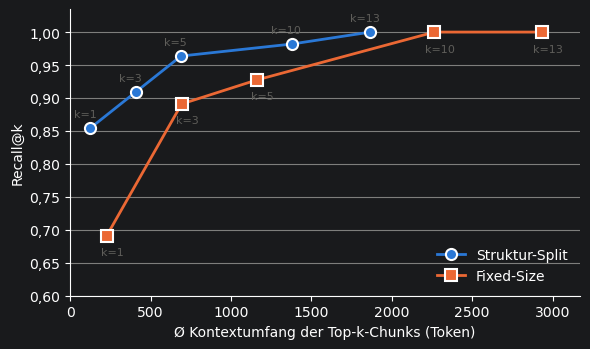

In [15]:
darstellung = {
    "Struktur": {"label": "Struktur-Split", "farbe": "#2a78d6", "marker": "o", "versatz": (-4, 8)},
    "Fixed":    {"label": "Fixed-Size",     "farbe": "#eb6834", "marker": "s", "versatz": (4, -14)},
}

fig, ax = plt.subplots(figsize=(6, 3.6))

for strategie, s in darstellung.items():
    x = [kontext_tokens[strategie][k] for k in K_WERTE]
    y = [np.mean(recall[strategie][k]) for k in K_WERTE]
    ax.plot(x, y, color=s["farbe"], lw=2, marker=s["marker"], ms=8,
            markeredgecolor="white", markeredgewidth=1.5, label=s["label"], zorder=3)
    # k an jeden Punkt schreiben
    for k, xi, yi in zip(K_WERTE, x, y):
        ax.annotate(f"k={k}", (xi, yi), textcoords="offset points", xytext=s["versatz"],
                    fontsize=8, color="#5f5e5a", ha="center")

ax.set_xlabel("Ø Kontextumfang der Top-k-Chunks (Token)")
ax.set_ylabel("Recall@k")
ax.yaxis.set_major_formatter(FuncFormatter(lambda wert, _: f"{wert:.2f}".replace(".", ",")))
ax.set_ylim(0.6, 1.035)
ax.set_xlim(0, max(kontext_tokens["Fixed"].values()) * 1.08)
ax.grid(axis="y", color="#e4e3dd", lw=0.8)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()

fig.savefig("recall_kontext.pdf", bbox_inches="tight")
plt.show()

## 13. Mögliche Ursache: Verwässerung

Vermutung: Ein Fixed-Size-Chunk enthält oft mehrere Absätze zu unterschiedlichen Themen, sodass sein Embedding nicht mehr eindeutig zu einer Frage passt. Wenn das stimmt, müsste der richtige Absatz bei den Fixed-Size-Chunks, die nicht auf Rang 1 landen, einen kleineren Anteil am Text haben als bei denen auf Rang 1.

Die Tabelle zeigt außerdem alle Fragen, bei denen nur eine der beiden Strategien auf Rang 1 trifft.

In [16]:
def gold_anteil(chunk, frage):
    # Anteil des Chunk-Textes, der zum richtigen Absatz gehört
    text = dokumente[chunk.metadata["quelle"]]
    start = text.find(chunk.page_content)
    ende = start + len(chunk.page_content)
    for nummer, p_start, p_ende in absatz_spans(text):
        if nummer in frage["gold"]:
            ueberlappung = max(0, min(ende, p_ende) - max(start, p_start))
            return ueberlappung / len(chunk.page_content)
    return 0.0


anteil_rang_1 = []
anteil_dahinter = []

print(f"{'Frage':>5}  {'Gold':24s} {'Rang F':>6} {'Rang S':>6} {'Anteil F':>8}")
for n, q in enumerate(fragen):
    platz_f, chunk_f = erster_treffer(q, ranglisten["Fixed"][n], fixed_chunks)
    platz_s = raenge["Struktur"][n]
    anteil = gold_anteil(chunk_f, q)

    if platz_f == 1:
        anteil_rang_1.append(anteil)
    else:
        anteil_dahinter.append(anteil)

    # nur Fragen, bei denen genau eine Strategie auf Rang 1 trifft
    if (platz_f == 1) != (platz_s == 1):
        gold = f"{q['quelle'][:14]} {q['gold'][0]}"
        print(f"{q['id']:>5}  {gold:24s} {platz_f:>6} {platz_s:>6} {anteil:>8.0%}")

print(f"\nFixed-Chunk auf Rang 1:  n = {len(anteil_rang_1):>2}, Ø Anteil richtiger Absatz {np.mean(anteil_rang_1):.0%}")
print(f"Fixed-Chunk dahinter:    n = {len(anteil_dahinter):>2}, Ø Anteil richtiger Absatz {np.mean(anteil_dahinter):.0%}")

Frage  Gold                     Rang F Rang S Anteil F
    1  2014-03_chapte 2.17           1      5      18%
    2  2014-03_chapte 2.2            4      1      22%
    3  2014-08_gmp_ch 8.17           2      1      32%
    7  2014-11_vol4_c 6.21           2      1      27%
   11  20220825_gmp-a 3.2           10      1      29%
   14  20220825_gmp-a 4.13           1      2      44%
   18  20220825_gmp-a 7.4            2      1      59%
   20  20220825_gmp-a 8.22           6      1      51%
   24  20220825_gmp-a 8.68           3      1      17%
   25  20220825_gmp-a 8.73           2      1      36%
   30  20220825_gmp-a 8.106          2      1      66%
   32  20220825_gmp-a 9.38           2      1      65%
   52  vol4-chap1_201 1.10           3      1      51%

Fixed-Chunk auf Rang 1:  n = 38, Ø Anteil richtiger Absatz 49%
Fixed-Chunk dahinter:    n = 17, Ø Anteil richtiger Absatz 37%


## 14. Signifikanztests

**Vorzeichentest (zweiseitig):** Für jedes k werden nur die Fragen betrachtet, bei denen genau eine Strategie trifft. Wenn es keinen Unterschied gibt, müsste jede Strategie etwa gleich oft gewinnen (Wahrscheinlichkeit 0,5).

**Mann-Whitney-U-Test (einseitig):** Prüft, ob der Anteil des richtigen Absatzes bei den Fixed-Size-Chunks auf Rang 1 größer ist als dahinter. Einseitig, weil die Vermutung aus Schritt 13 die Richtung vorgibt.

Als Signifikanzniveau werden jeweils 5 % verwendet.

In [17]:
for k in K_WERTE:
    nur_struktur = 0
    nur_fixed = 0
    for f, s in zip(recall["Fixed"][k], recall["Struktur"][k]):
        if s > f:
            nur_struktur += 1
        elif f > s:
            nur_fixed += 1

    n = nur_struktur + nur_fixed
    if n > 0:
        p = binomtest(nur_fixed, n, 0.5).pvalue
    else:
        p = 1.0
    print(f"k={k:<2d}  nur Struktur {nur_struktur:>2}  nur Fixed {nur_fixed:>2}  Vorzeichentest p = {p:.3f}")

p_mw = mannwhitneyu(anteil_rang_1, anteil_dahinter, alternative="greater").pvalue
print(f"\nMann-Whitney-U (einseitig): p = {p_mw:.3f}")

k=1   nur Struktur 11  nur Fixed  2  Vorzeichentest p = 0.022
k=3   nur Struktur  4  nur Fixed  3  Vorzeichentest p = 1.000
k=5   nur Struktur  3  nur Fixed  1  Vorzeichentest p = 0.625
k=10  nur Struktur  0  nur Fixed  1  Vorzeichentest p = 1.000
k=13  nur Struktur  0  nur Fixed  0  Vorzeichentest p = 1.000

Mann-Whitney-U (einseitig): p = 0.066
